TIME SERIES ANALYSIS OF DENVER CRIME DATA

In [60]:
# import nbformat
# from IPython import get_ipython

# with open("STUTI_TIWARI_EDA.ipynb", encoding='utf-8') as f:
#     nb = nbformat.read(f, as_version=4)

# for cell in nb.cells:
#     if cell.cell_type == 'code':
#         get_ipython().run_cell(cell.source)

In [70]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
from prophet.plot import plot_components_plotly
import seaborn as sns

In [62]:
# reading in the data
crime_df = pd.read_csv("data/crime_data.csv", parse_dates=["REPORTED_DATE"])
crime_df.set_index("REPORTED_DATE", inplace=True)

C:\Users\stuti\AppData\Local\Temp\ipykernel_6792\3266003237.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df = pd.read_csv("data/crime_data.csv", parse_dates=["REPORTED_DATE"])


In [63]:
# unique values in OFFENSE_TYPE_ID
print("Unique OFFENSE_TYPE_IDs:")
print(crime_df['OFFENSE_TYPE_ID'].unique())
# unique values in OFFENSE_CATEGORY_ID
print("\nUnique OFFENSE_CATEGORY_IDs:")
print(crime_df['OFFENSE_CATEGORY_ID'].unique())

Unique OFFENSE_TYPE_IDs:
['assault-simple' 'criminal-mischief-other' 'public-order-crimes-other'
 'burglary-business-no-force' 'violation-of-restraining-order'
 'police-resisting-arrest' 'police-obstruct-investigation'
 'police-false-information' 'police-disobey-lawful-order'
 'police-interference' 'violation-of-court-order' 'escape'
 'intimidation-of-a-witness' 'weapon-fire-into-occ-bldg'
 'parole-violation' 'probation-violation' 'weapon-carrying-prohibited'
 'explosive-incendiary-dev-use' 'explosive-incendiary-dev-pos'
 'weapon-poss-illegal-dangerous' 'weapon-unlawful-discharge-of'
 'theft-of-motor-vehicle' 'weapon-by-prev-offender-powpo'
 'theft-from-bldg' 'robbery-street' 'disturbing-the-peace'
 'weapon-flourishing' 'criminal-trespassing' 'harassment'
 'aggravated-assault' 'drug-pcs-other-drug' 'public-fighting'
 'wiretapping' 'contraband-possession' 'contraband-into-prison'
 'animal-cruelty-to' 'illegal-dumping' 'littering'
 'other-enviornment-animal-viol' 'animal-poss-of-dangerou

In [64]:
# resampling to monthly
monthly_crime = crime_df.resample('M').size()
print(monthly_crime)

C:\Users\stuti\AppData\Local\Temp\ipykernel_6792\4116099323.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_crime = crime_df.resample('M').size()


REPORTED_DATE
2020-01-31    4124
2020-02-29    3698
2020-03-31    3909
2020-04-30    4207
2020-05-31    5048
2020-06-30    5185
2020-07-31    5577
2020-08-31    5661
2020-09-30    5506
2020-10-31    5512
2020-11-30    5150
2020-12-31    5587
2021-01-31    6025
2021-02-28    5068
2021-03-31    5508
2021-04-30    5539
2021-05-31    6195
2021-06-30    6190
2021-07-31    6337
2021-08-31    6187
2021-09-30    5794
2021-10-31    5792
2021-11-30    5641
2021-12-31    5805
2022-01-31    6057
2022-02-28    5603
2022-03-31    6420
2022-04-30    6146
2022-05-31    6503
2022-06-30    6075
2022-07-31    6385
2022-08-31    6531
2022-09-30    6222
2022-10-31    6301
2022-11-30    5694
2022-12-31    5587
2023-01-31    6302
2023-02-28    5434
2023-03-31    5753
2023-04-30    5592
2023-05-31    6135
2023-06-30    6275
2023-07-31    6580
2023-08-31    6321
2023-09-30    5850
2023-10-31    5859
2023-11-30    5405
2023-12-31    5518
2024-01-31    5498
2024-02-29    4924
2024-03-31    5087
2024-04-30    514

Time Series of Crime Counts Per Group

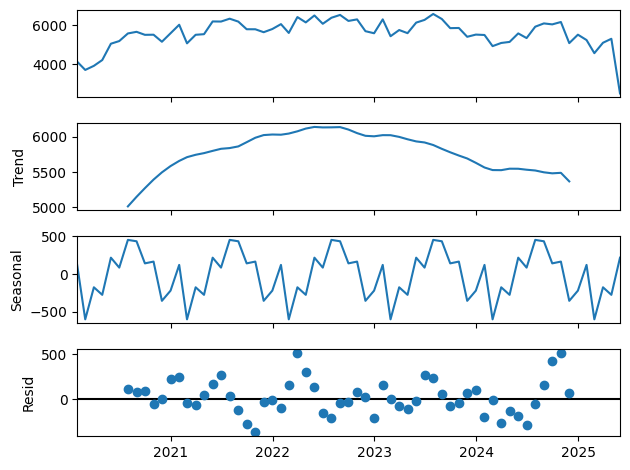

In [65]:
result = seasonal_decompose(monthly_crime, model='additive', period=12)
result.plot();

We can notice a trend here-
2020–2022: Crime increased significantly (These were pandemic years so that could be one reason)
2023–2025: A slight decline

17:46:12 - cmdstanpy - INFO - Chain [1] start processing
17:46:13 - cmdstanpy - INFO - Chain [1] done processing


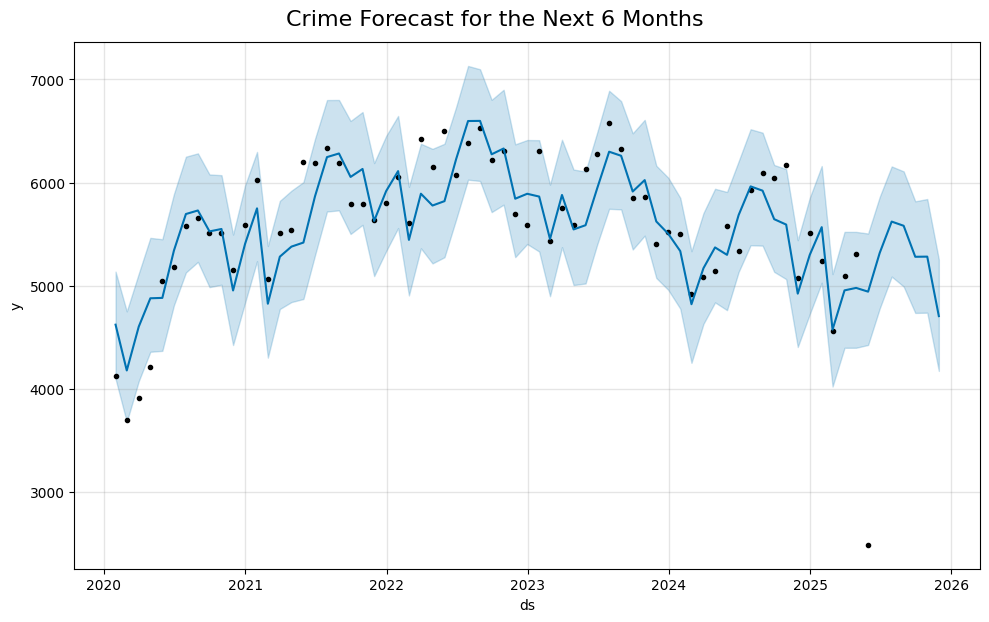

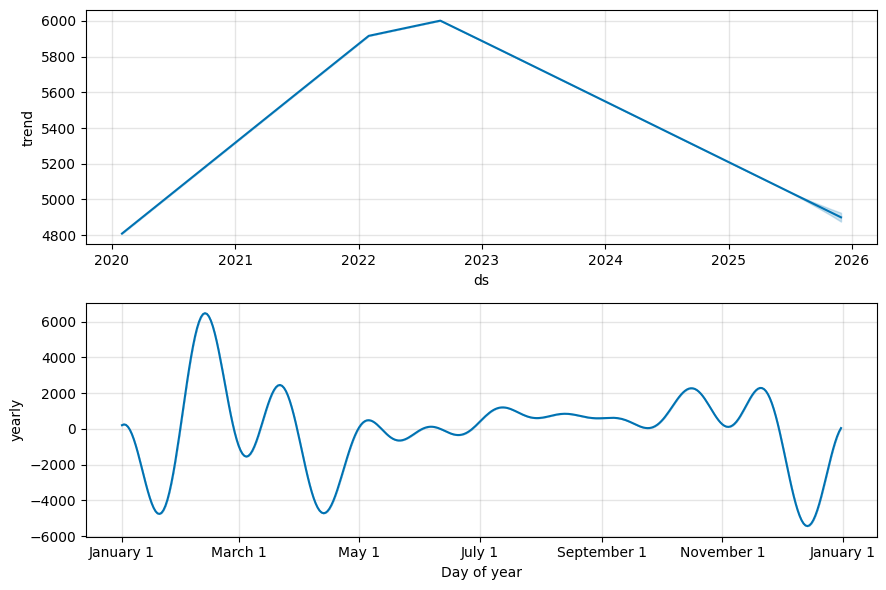

In [ ]:
# data preparation
df_prophet = monthly_crime.reset_index()
df_prophet.columns = ['ds', 'y']

# initializing and fitting the model
model = Prophet()
model.fit(df_prophet)

# forecast for the next 6 months
future = model.make_future_dataframe(periods=6, freq='ME')
forecast = model.predict(future)
fig1 = model.plot(forecast)
fig1.suptitle("Crime Forecast for the Next 6 Months", fontsize=16, y=1.03)
fig2 = model.plot_components(forecast)

Crime Category wise time series prediction

C:\Users\stuti\AppData\Local\Temp\ipykernel_6792\3052355389.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  category_monthly = (crime_df.groupby([pd.Grouper(freq='M'), 'OFFENSE_CATEGORY_ID']).size().reset_index(name='count'))
17:28:40 - cmdstanpy - INFO - Chain [1] start processing
17:28:40 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\stuti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
17:28:41 - cmdstanpy - INFO - Chain [1] start processing
17:28:41 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\stuti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecate

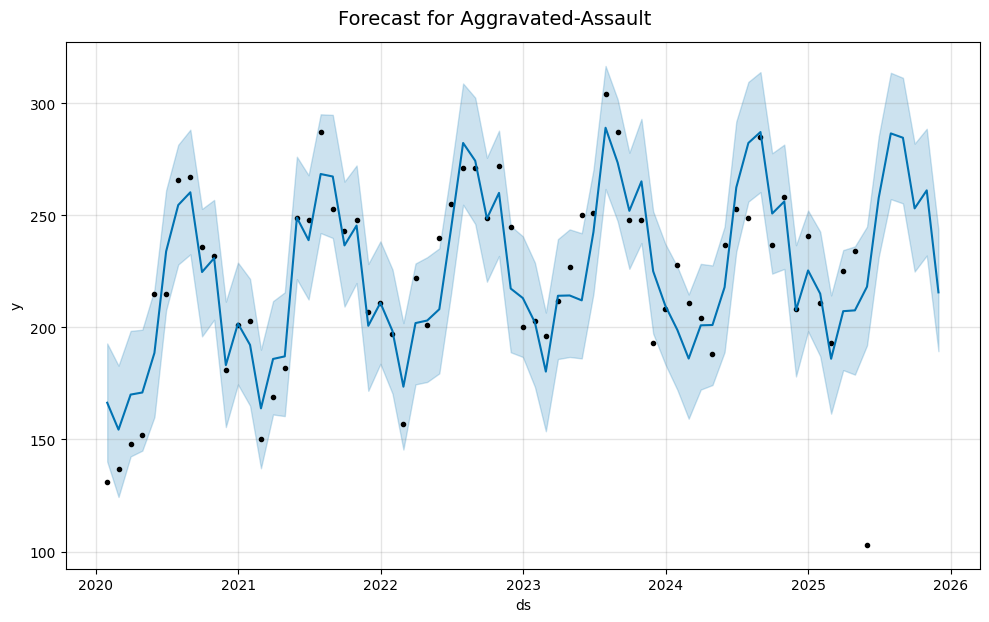

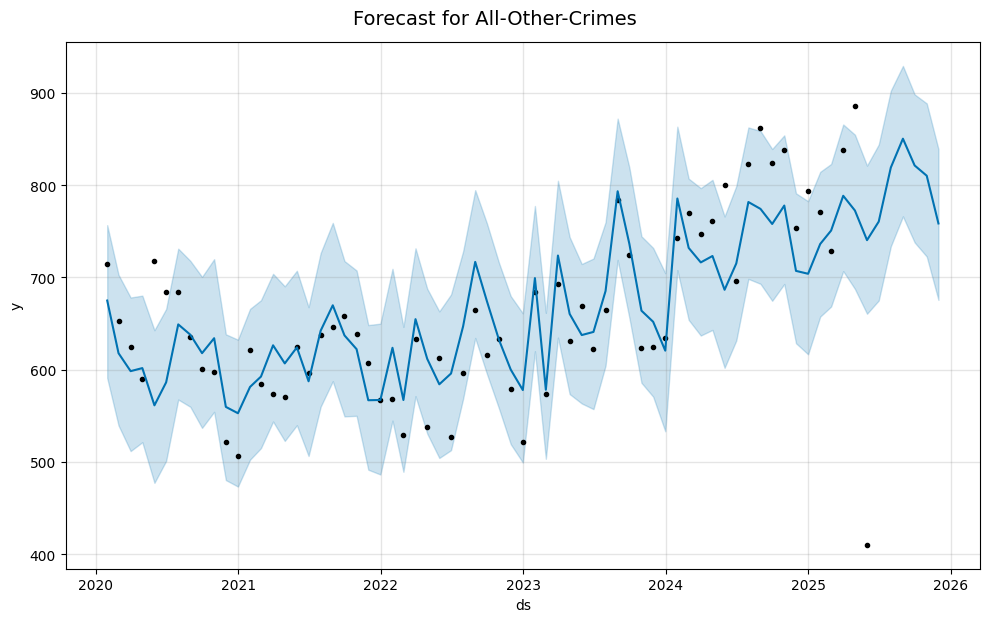

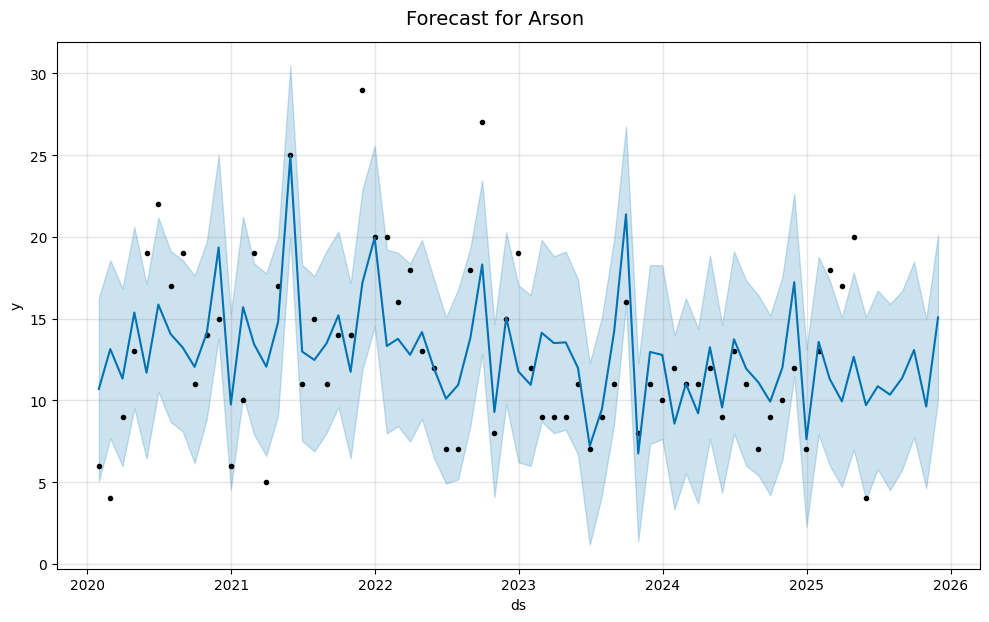

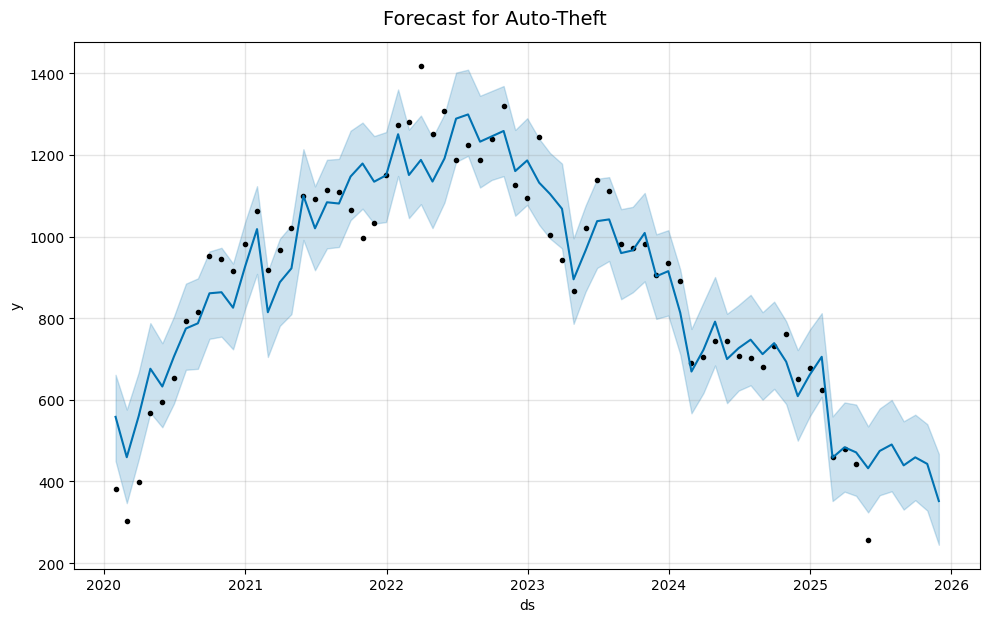

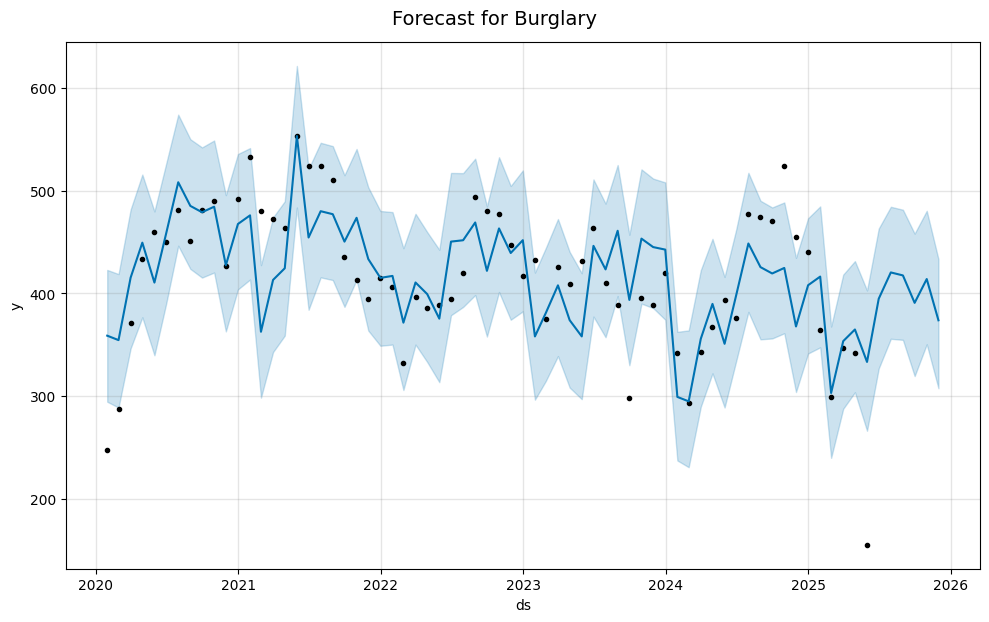

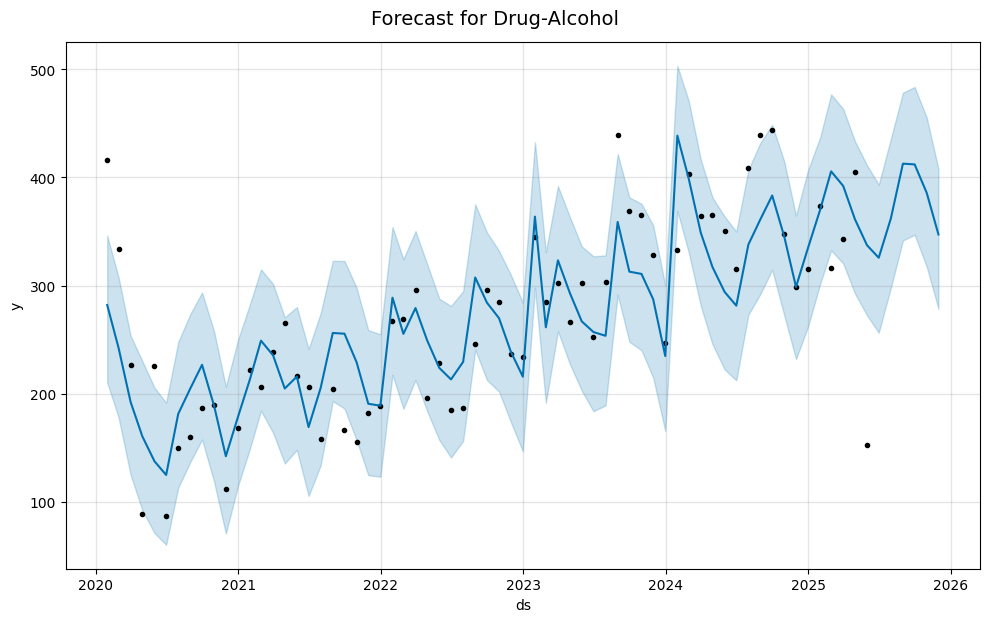

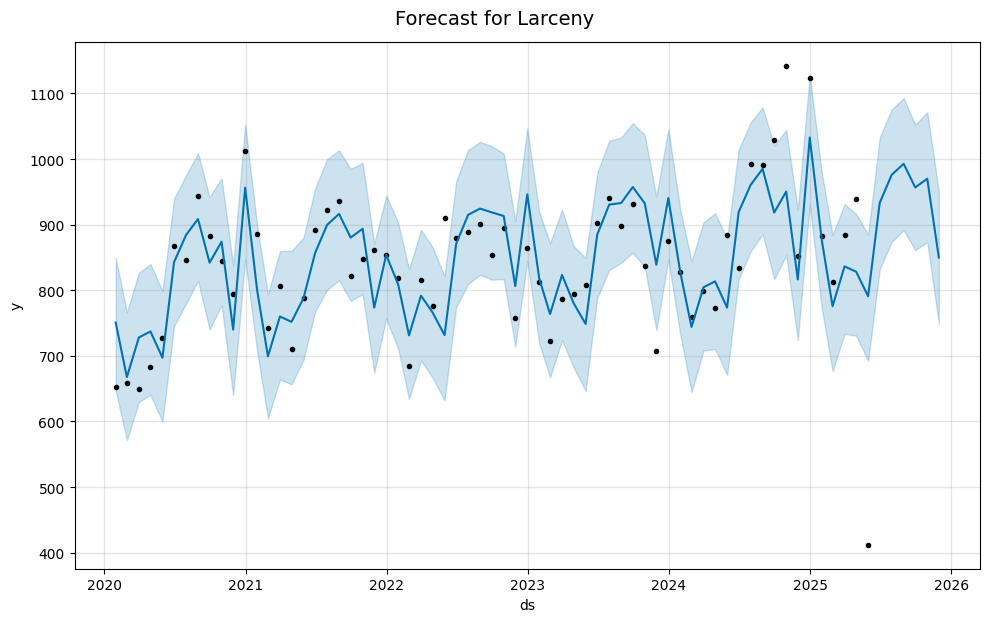

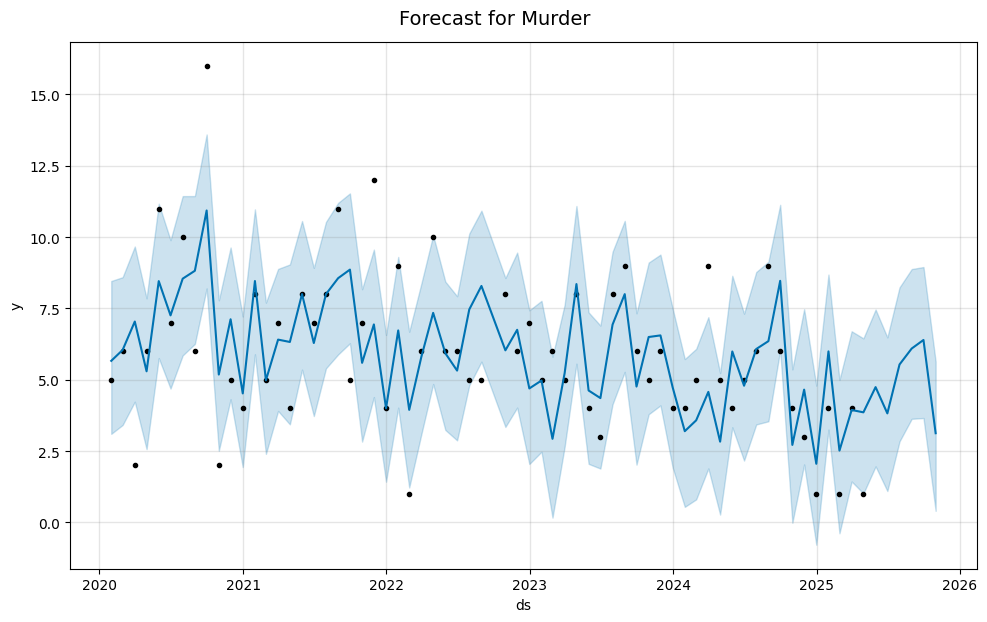

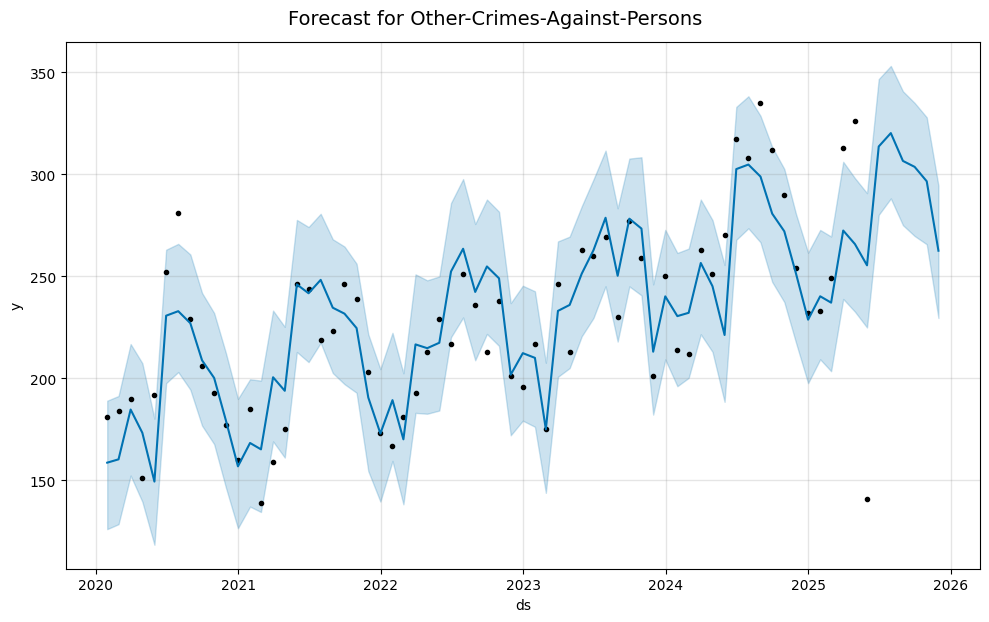

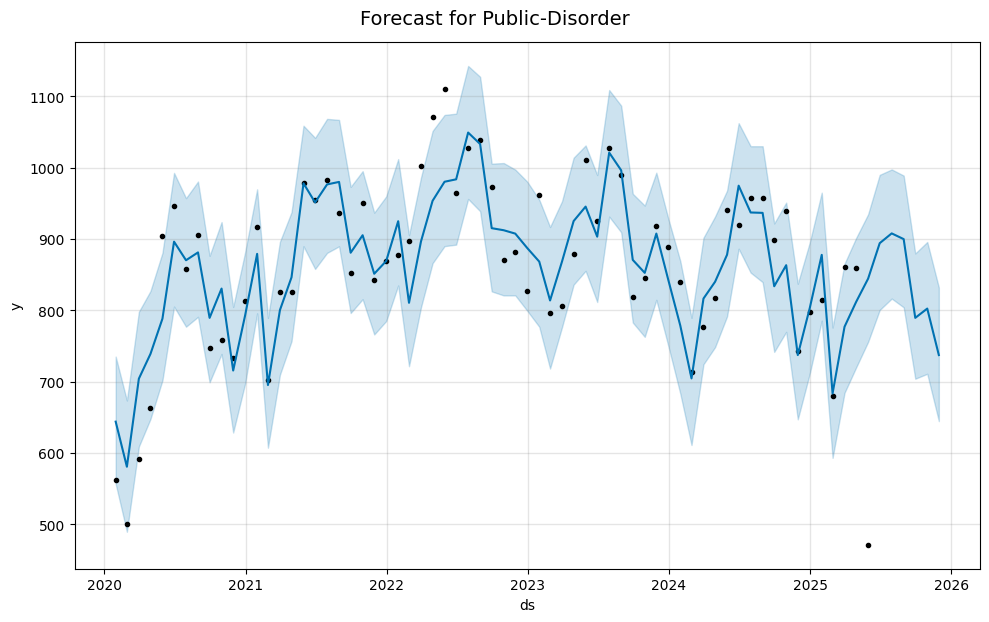

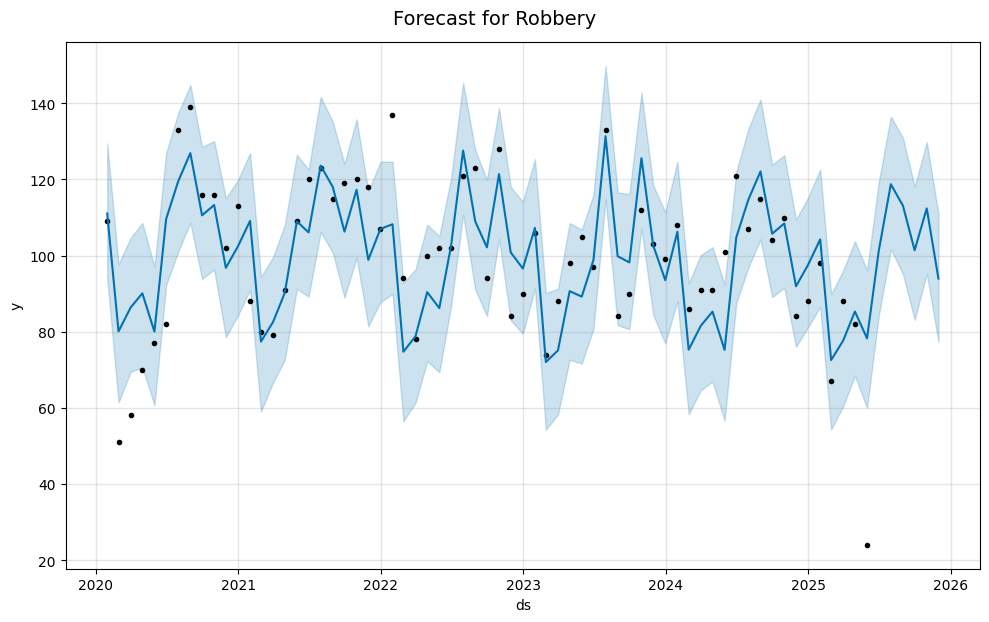

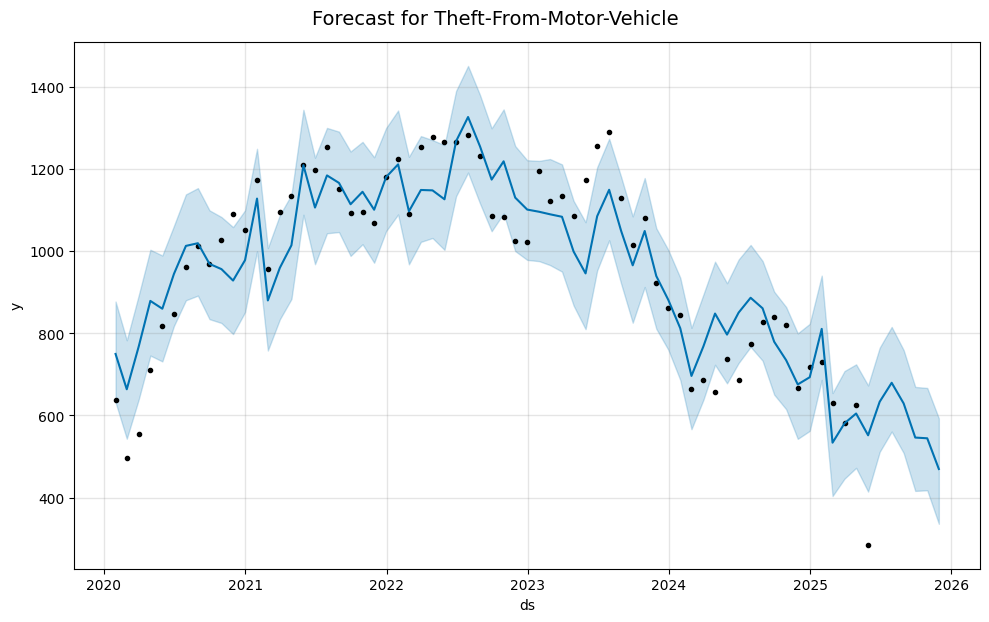

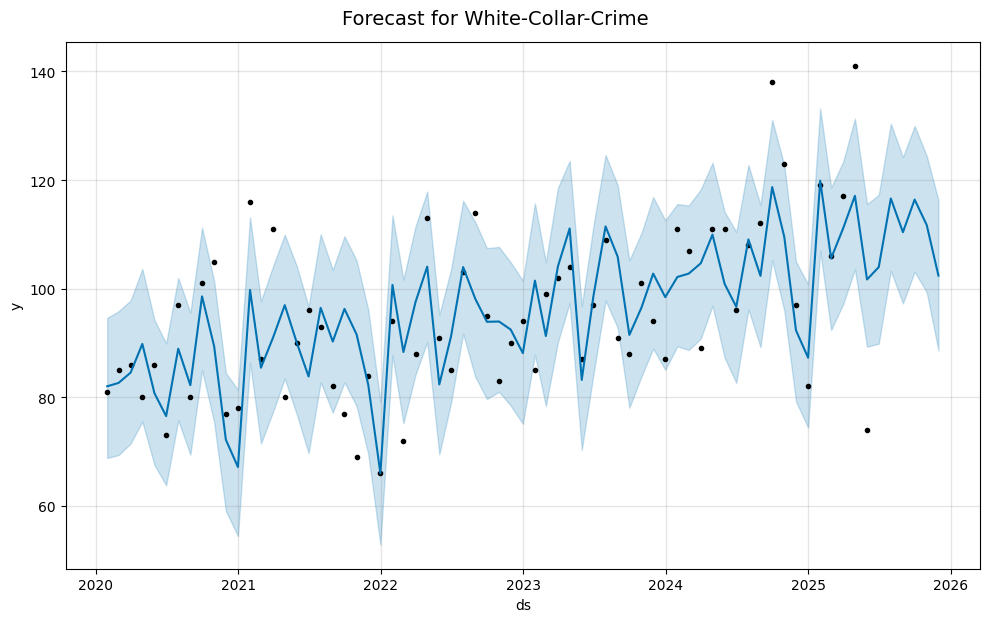

In [ ]:
# grouping by month and category
category_monthly = (crime_df.groupby([pd.Grouper(freq='M'), 'OFFENSE_CATEGORY_ID']).size().reset_index(name='count'))

# looping over each crime
unique_categories = category_monthly['OFFENSE_CATEGORY_ID'].unique()
for category in unique_categories:
    df_cat = category_monthly[category_monthly['OFFENSE_CATEGORY_ID'] == category]
    df_cat = df_cat.rename(columns={'REPORTED_DATE': 'ds', 'count': 'y'})
    df_cat = df_cat[['ds', 'y']]
    # if there are very few data points then we skip
    if len(df_cat) < 24:
        continue
    model = Prophet()
    model.add_country_holidays(country_name='US')
    model.fit(df_cat)
    future = model.make_future_dataframe(periods=6, freq='ME')
    forecast = model.predict(future)
    fig = model.plot(forecast)
    fig.suptitle(f"Forecast for {category.title()}", y=1.03, fontsize=14)

Top Crime type per neighbourhood per month

          MONTH NEIGHBORHOOD_ID       OFFENSE_CATEGORY_ID  count
2    2020-01-01     athmar-park                auto-theft     12
697  2020-02-01     athmar-park              drug-alcohol      9
1373 2020-03-01     athmar-park  theft-from-motor-vehicle     13
2054 2020-04-01     athmar-park  theft-from-motor-vehicle      9
2727 2020-05-01     athmar-park           public-disorder     11


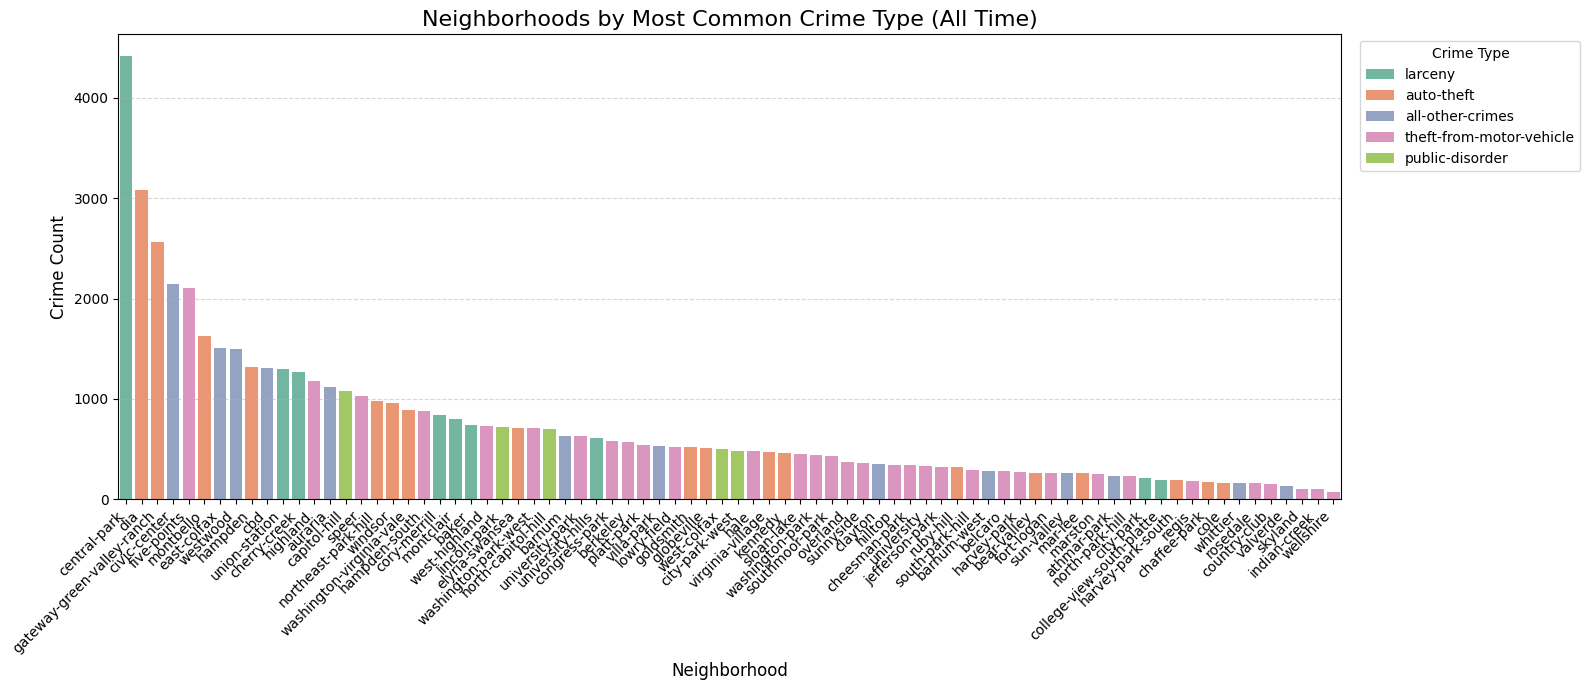

In [ ]:
#print(crime_df.head())
crime_df['MONTH'] = crime_df.index.to_period('M').to_timestamp()

# counting the crime occurences per month per neighbourhood and catrgory
grouped = (crime_df.groupby(['MONTH', 'NEIGHBORHOOD_ID', 'OFFENSE_CATEGORY_ID']).size().reset_index(name='count'))

# getting the top crime types
top_crime_monthly = (grouped.sort_values('count', ascending=False).drop_duplicates(['MONTH', 'NEIGHBORHOOD_ID']).sort_values(['NEIGHBORHOOD_ID', 'MONTH']))
print(top_crime_monthly.head())

# plotting denver neighbourhoods by most common crime type
top_alltime = (top_crime_monthly.groupby(['NEIGHBORHOOD_ID', 'OFFENSE_CATEGORY_ID'])['count'].sum().reset_index())
top_overall = top_alltime.sort_values('count', ascending=False).drop_duplicates('NEIGHBORHOOD_ID')
plot_df = top_overall.sort_values('count', ascending=False)

# plot
plt.figure(figsize=(16, 7))
ax = sns.barplot(data=plot_df,x='NEIGHBORHOOD_ID',y='count',hue='OFFENSE_CATEGORY_ID',dodge=False,palette='Set2')
plt.title("Neighborhoods by Most Common Crime Type (All Time)", fontsize=16)
plt.xlabel("Neighborhood", fontsize=12)
plt.ylabel("Crime Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Crime Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

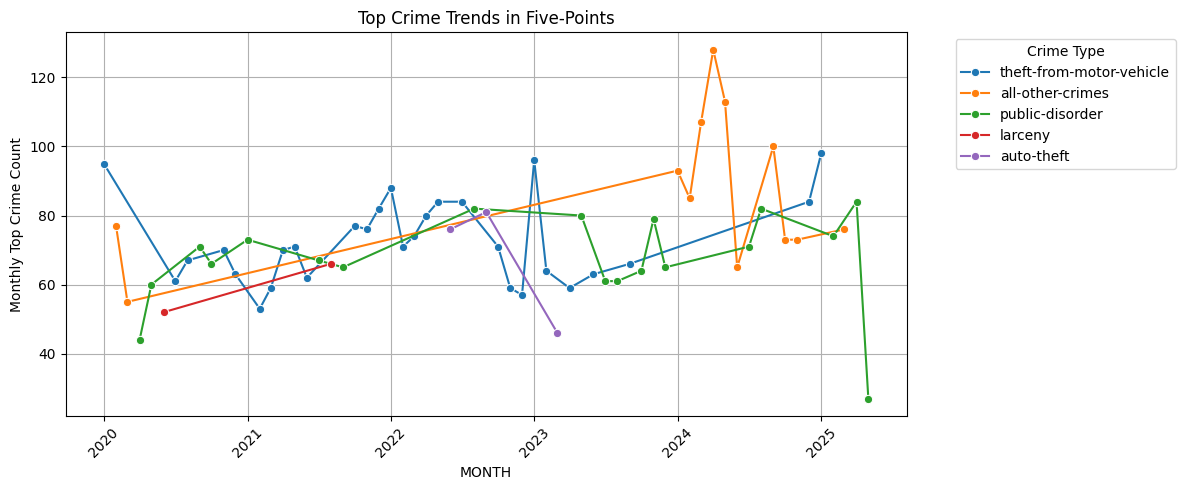

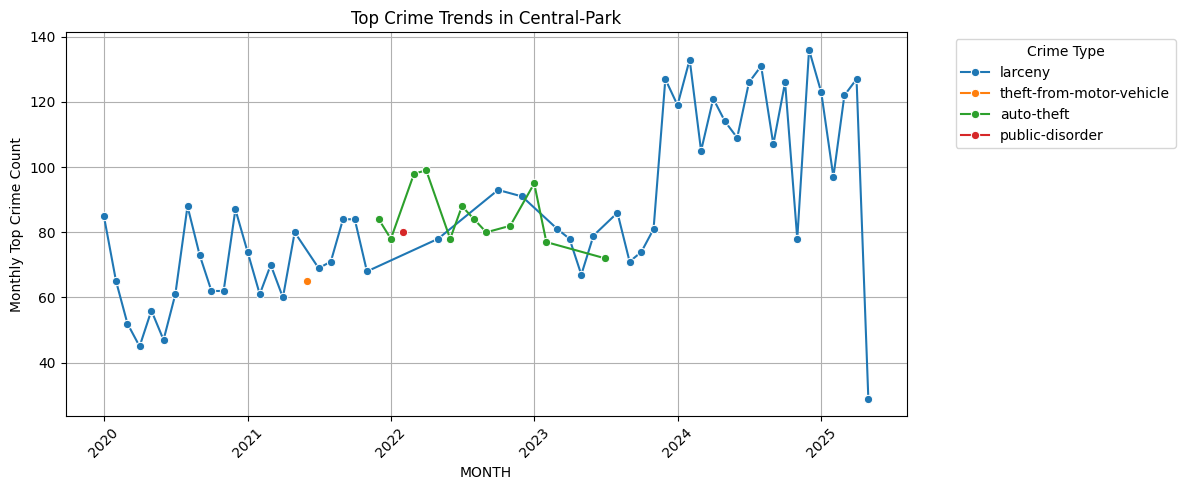

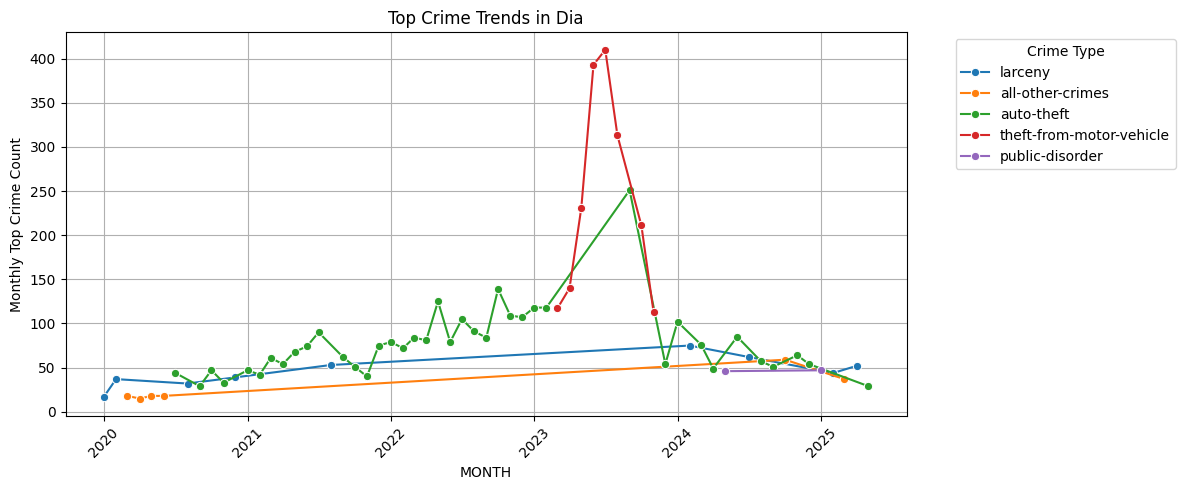

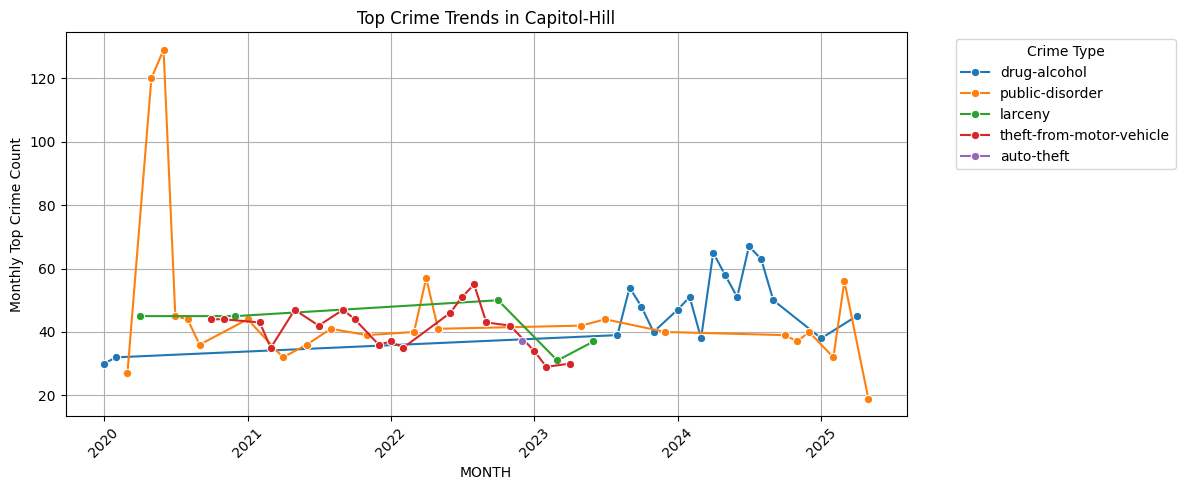

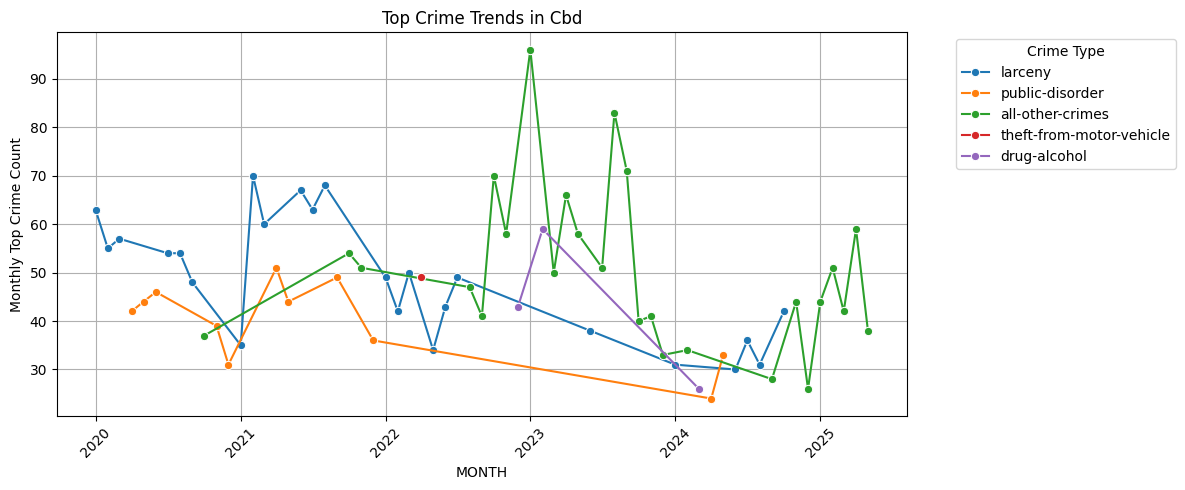

In [ ]:
# visualizing top crimes for the top 5 neighbourhoods with most crimes
top_nhoods = (crime_df['NEIGHBORHOOD_ID'].value_counts().head(5).index.tolist())
top_crime_top5 = top_crime_monthly[top_crime_monthly['NEIGHBORHOOD_ID'].isin(top_nhoods)]
for nhood in top_nhoods:
    subset = top_crime_top5[top_crime_top5['NEIGHBORHOOD_ID'] == nhood]
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=subset, x='MONTH', y='count', hue='OFFENSE_CATEGORY_ID', marker='o')
    plt.title(f"Top Crime Trends in {nhood.title()}")
    plt.ylabel("Monthly Top Crime Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()